# Modelos de Deep Learning: Aplicaciones prácticas

# **Tarea 1**



# 🤖 **Análisis de Modelos de Deep Learning: Del Puntos a Neuronas**

En este proyecto exploramos el pipeline completo del aprendizaje automático: desde la generación y preparación de datos hasta la optimización de parámetros. A través de la práctica con TensorFlow y NumPy, implementamos tres soluciones clave para entender cómo una máquina "aprende" a decidir.

**A. Clasificador Lineal: Dibujando la Frontera**

El objetivo es encontrar la separación óptima entre dos grupos de datos. Este modelo es la base de las redes neuronales y funciona bajo los siguientes principios:

*   **Parámetros ($W$ y $b$):**

**Pesos ($W$):** Representan la importancia de cada característica ($x_1, x_2$). Técnicamente, definen la inclinación de nuestra frontera.

**Sesgo ($b$):** Es el término independiente que nos permite desplazar la línea en el plano, evitando que quede anclada al origen $(0,0)$.


*   **Lógica de Predicción:** El modelo calcula la ecuación $z = x \cdot W + b$. Para decidir, aplicamos un umbral (threshold):

Si el resultado es **menor a 0.5**, el punto se asigna a la **Clase 0 (Verde)**.

Si el resultado es **mayor a 0.5**, el punto se asigna a la **Clase 1 (Rojo)**.

*   **La Frontera:** La "línea de decisión" es el lugar geométrico donde el resultado es exactamente 0.5, marcando el límite donde una clase se convierte en la otra.


**B. Regresión Lineal: "Encontrando la tendencia"**

A diferencia del clasificador, aquí buscamos predecir un valor continuo. Es el arte de encontrar la mejor rampa que atraviese una nube de puntos con el menor error posible.


*   **Cálculo del Error (MSE):** Utilizamos el Error Cuadrático Medio para medir matemáticamente qué tan lejos están nuestras predicciones de la realidad.
*   **Optimización con tf.GradientTape():** Esta herramienta actúa como una "grabadora" de operaciones. Al detectar un error, nos permite calcular los gradientes (la dirección del error) para ajustar los parámetros.
*   **Descenso por Gradiente:** Es el núcleo del aprendizaje. El modelo se actualiza restando una fracción del gradiente (ajustada por el learning rate), logrando que en cada iteración la rampa se acerque más a la perfección.


**C. Redes Neuronales: "Copiando al cerebro" (Dataset Iris)**

Cuando los datos son complejos y una línea recta no basta, recurrimos a una arquitectura inspirada en el cerebro humano, implementada desde cero con NumPy.


*   **Capas Ocultas:** Creamos un pequeño "cerebro artificial" con 4 neuronas ocultas. Cada neurona actúa como un pequeño detector de patrones que analiza el largo y ancho del sépalo.

*   **Flexibilidad:** Al combinar estas neuronas, el modelo deja de ser rígido y puede entender patrones mucho más complejos. Gracias a esto, y tras 10,000 iteraciones de aprendizaje (propagar el error hacia atrás o backpropagation), logramos una precisión del 100% en la clasificación de las flores.

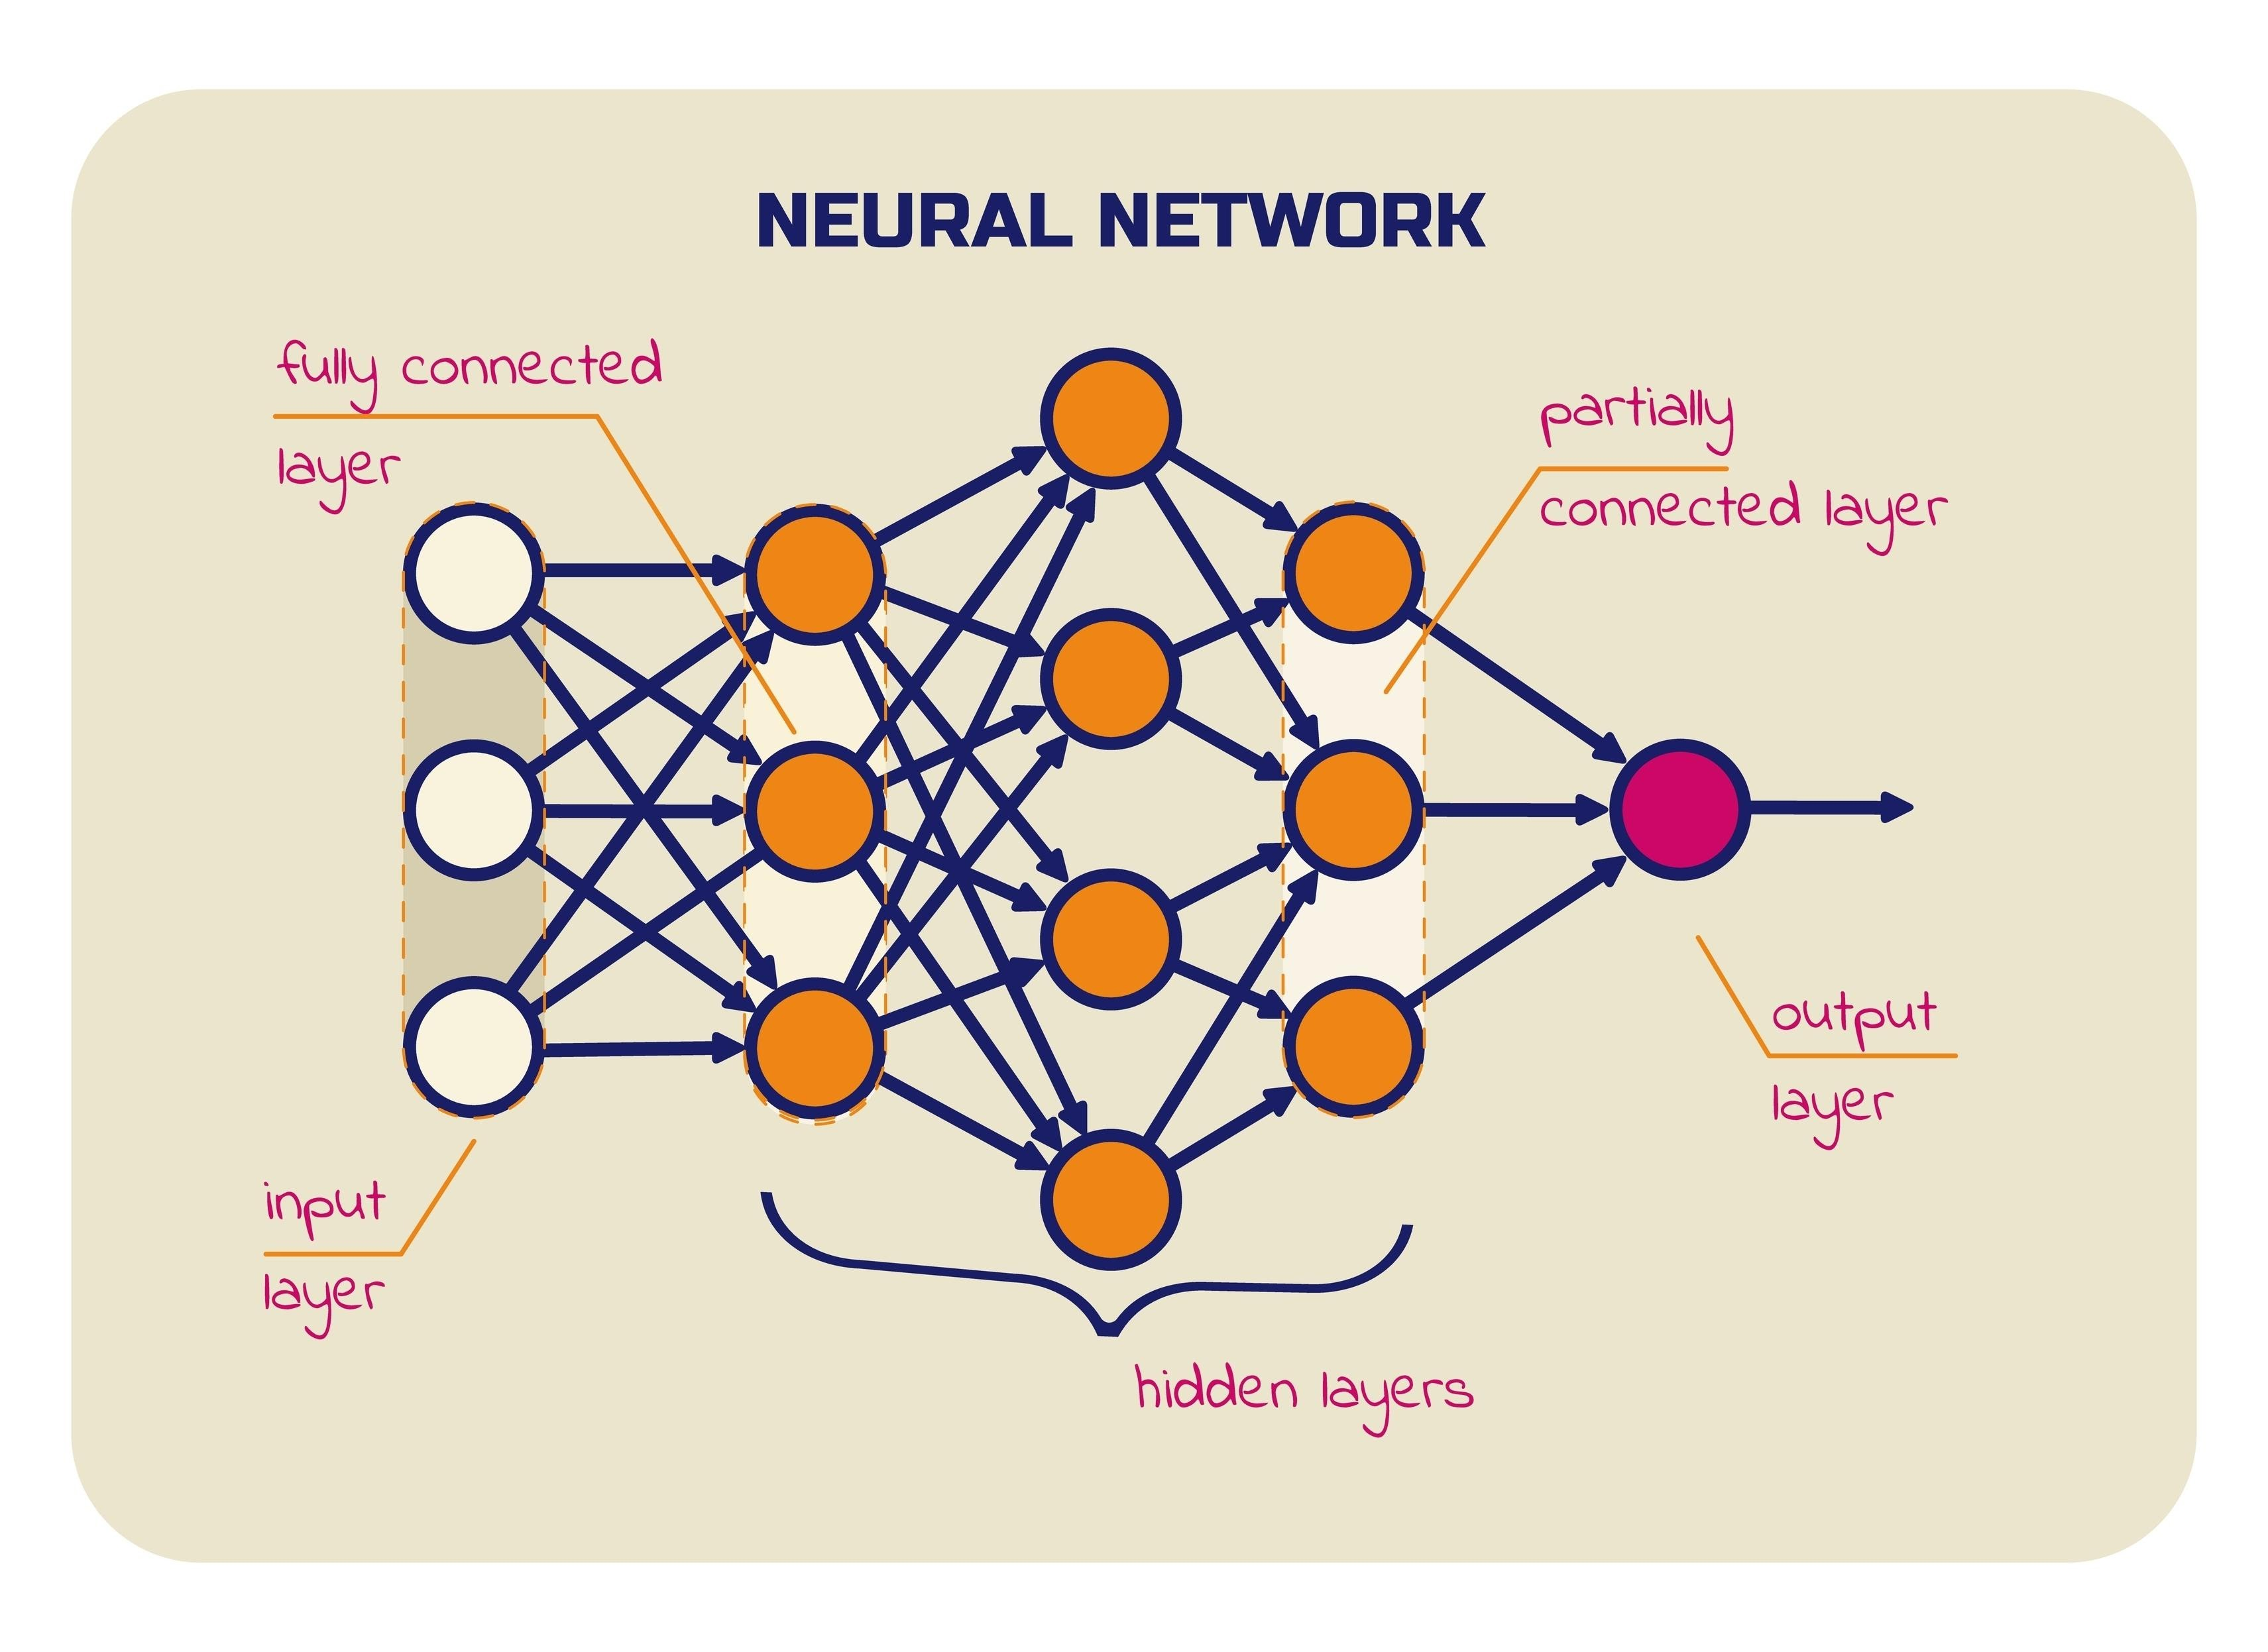









✨ **Aplicación práctica: Análisis de Modelos de Deep Learning en "NUBE ANDINA"** 🦙👟

🛡️ **ETAPA 1: Separando la fibra (Clasificador Lineal inspirado en el Problema 1) El modelo que separa dos grupos** 🕵️‍♀️

En Nube Andina, lo más importante es que la fibra sea de calidad. Si voy a hacer un zapato "100% Alpaca Premium" 💎, no puede haber ni un poquito de lana de oveja en la capellada.

**¿Cómo lo haría?** Usaría un  fibrómetro digital y una cámara profesional para que tome fotos a las fibras mientras pasan por la máquina 📸

Usando el código del colab, este modelo aprenderá a distinguir si es fibra de alpaca premium o lana de oveja mirando el grosor y la textura.

**La decisión:** Si el modelo dice que es fibra de alpaca premium (un número mayor a 0.5), ¡estamos listos! ✅ Pero si dice que es lana de oveja, un soplador de aire la aparta a otro lado 💨🌬️

📉  **ETAPA 2: ¿Cuánta alpaca le pongo para que no se rompa?**

**Regresión Lineal, inspirado en el Problema 2: El modelo que predice números** 🧵🤔

La alpaca es suavecita, pero la oveja ayuda a que el zapato sea más firme. El desafío es: ¿Cuál es la mezcla exacta para que el zapato dure años?


*   **Mi experimento:** En el taller, estiramos telas con diferentes mezclas hasta que se rompen para ver cuánta fuerza aguantan 💪
*   Usando el código de colab, el código de "Regresión" para que dibuje una línea mágica. Esa línea me dirá: "si quieres que el zapato sea súper resistente, mézcla exactamente 78% de alpaca" ⚙️📏

Resultado: Dejo de adivinar y uso el código para fabricar calzado de fibra de alpca de calidad.

🧠 **ETAPA 3: "Inspector Inteligente" (Red Neuronal, inspirado en el Problema 3)**🤖🧐

Cuando el zapato de fibra de alpaca premium ya está terminado, tiene que estar perfecto, alienado a los estándares de calidad para exportar. Pero a veces a uno se le pasan detallitos, por eso, usaré una "Red Neuronal".

**¿Cómo funciona?** Pasamos el zapato por una máquina que revisa el color y qué tan ajustado quedó el tejido 📈

Usando el código de colab "redes neuronales", revisará el zapato (color, resistencia, calidad de la fibra de alpaca).

Si el cerebro artificial dice que el zapato tiene un 98% de probabilidad de estar perfecto, se va directo a su caja 📦✨ Si no, lo revisamos de nuevo para que nada salga mal.


---
# PROBLEMA 1
## Clasificador lineal en TensorFlow

**Modificaciones solicitadas:**
1. Cambiar color del conjunto superior a verde y del inferior a rojo
2. Cambiar matriz de covarianza para que las nubes sean casi esféricas
3. Dibujar línea de decisión negra discontinua en lugar de roja

**Generando dos clases de puntos aleatorios en un plano 2D**

#**Paso 1: Generación de Datos (Nubes Esféricas)**
**Generación de nubes de datos casi esféricas:** Para lograr que las nubes sean casi esféricas (circulares en 2D), ajustamos la matriz de covarianza a [[0.2, 0.0], [0.0, 0.2]]. Al poner los valores de fuera de la diagonal en 0.0, eliminamos la correlación entre x1 y x2, evitando que las nubes se vean alargadas.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

num_samples_per_class = 1000
# Matriz de covarianza casi esférica: valores pequeños en la diagonal, casi cero fuera
cov_esferica = [[0.1, 0.0], [0.0, 0.1]]
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=cov_esferica, size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=cov_esferica, size=num_samples_per_class)

💡 **Apilando las dos clases en un array con forma (2000, 2)**

En este paso estamos realizando una operación crítica dentro del Pipeline de Datos:


*   **Creación del Tensor de Entrada:** Al usar np.vstack, estamos construyendo una
matriz (o tensor) donde cada fila es un ejemplo (un punto en el plano) y cada columna es una característica o feature ($x_1$ y $x_2$).
*   **Consistencia de Datos:** El uso de .astype(np.float32) es fundamental. En Deep Learning, TensorFlow y las GPUs trabajan mucho más rápido con precisión de 32 bits que con la de 64 bits (que es el estándar de NumPy). Esto optimiza el uso de la memoria.

*   **Preparación para el Lote (Batching):** La forma (2000, 2) le dice al modelo: "Tengo 2000 registros para que aprendas, y cada uno tiene 2 dimensiones". Esto permite que, más adelante, el modelo pueda procesar todos los puntos al mismo tiempo mediante operaciones de álgebra lineal (multiplicación de matrices).




In [2]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [3]:
inputs.shape

(2000, 2)

🎯 **Generando los targets correspondientes (0 y 1)**

En esta sección estamos preparando las respuestas correctas para que nuestro modelo pueda comparar sus predicciones. Aquí los detalles clave:

**Etiquetado Binario:** Al usar np.zeros para la primera mitad y np.ones para la segunda, estamos creando un lenguaje que la computadora entiende.

*   **0:** Representa la Clase "Superior" (Verde).
*   **1:** Representa la Clase "Inferior" (Roja)



In [4]:
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

#**Paso 2: Asignación de Etiquetas y Colores**
**Clasificación y asignación de colores:** Asignamos la Clase 0 a la nube superior (Verde) y la Clase 1 a la nube inferior (Roja). Combinamos los datos en una sola matriz de entrada (inputs) y creamos el vector de etiquetas (targets) para el entrenamiento.

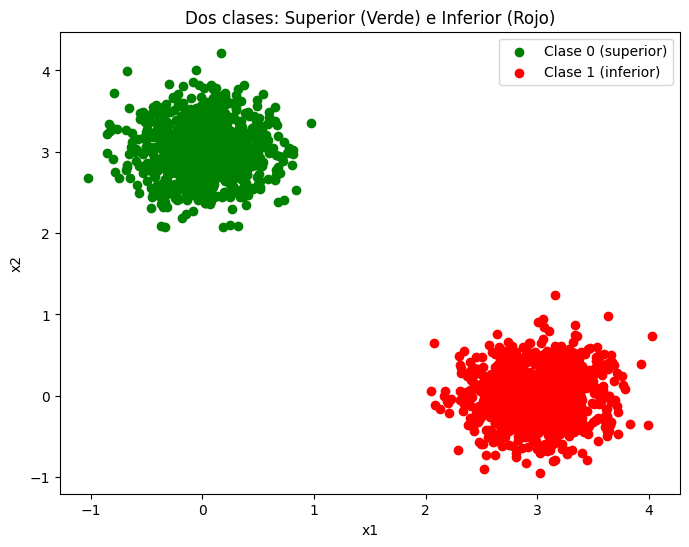

In [5]:
plt.figure(figsize=(8, 6))
mask0 = (targets[:, 0] == 0).flatten()
mask1 = (targets[:, 0] == 1).flatten()
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='green', label='Clase 0 (superior)')
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='red', label='Clase 1 (inferior)')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dos clases: Superior (Verde) e Inferior (Rojo)')
plt.show()

🏗️**Creando las variables del clasificador lineal**

Antes de lanzar el entrenamiento, necesito definir los componentes que el modelo va a manipular. En las clases y las lecturas aprendí que estos no son simples números, sino objetos que pueden cambiar con el tiempo:

*   Variables de TensorFlow (tf.Variable): Defino mis pesos ($W$) y mi sesgo ($b$) como variables. Esto es clave porque le aviso a TensorFlow, que estos valores no son fijos, necesito que los ajustes durante el entrenamiento.
*   Inicialización: Normalmente empezamos con valores aleatorios o ceros. Es como darle al modelo una "hoja en blanco" para que empiece a dibujar la línea de decisión.



#**Paso 3: Entrenamiento con Descenso por Gradiente**
**Entrenamiento del Clasificador con tf.GradientTape():** Utilizamos el ciclo de entrenamiento para ajustar los Pesos (W) y el Sesgo (b). El modelo utiliza tf.GradientTape para registrar la pérdida y calcular los gradientes que permiten mover la línea de decisión hacia la posición óptima de separación.

In [6]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

🧠 **Función de forward pass: El Corazón del Modelo**
Aquí es donde ocurre la magia matemática. Esta función es la que toma los datos de entrada y genera una predicción. Aunque se ve como una sola línea de código, lo que estoy haciendo es aplicar la lógica básica de una neurona:



*   **Multiplicación de matrices (tf.matmul): **Aquí mezclo mis datos (inputs) con los pesos (W). Como vi en los videos, esto es básicamente decirle al modelo qué tanta importancia debe darle a cada característica (en este caso, a las coordenadas $x_1$ y $x_2$).
*   **El toque de flexibilidad (+ b):** Sumo el sesgo o bias. Aprendí en las lecturas que esto es vital; si no lo pongo, mi línea de decisión siempre pasaría por el centro $(0,0)$ y no podría moverse libremente por el plano para separar bien los puntos.
*   **Resultado ($z$):** El valor que sale de aquí es mi predicción inicial. Es un número que después compararé con los targets reales para ver si el modelo acertó o si todavía necesita seguir entrenando.



In [7]:
def model(inputs):
    return tf.matmul(inputs, W) + b

📏 **Función de pérdida (error cuadrático medio)**

Después de obtener una predicción, necesito una forma de medir qué tan lejos estoy de la respuesta real. En las lecturas del curso vimos que el Error Cuadrático Medio (MSE) es ideal para esto:


*   **Diferencia de errores (targets - predictions):** Primero, simplemente resto lo que el modelo predijo de lo que debería haber salido. Esto me dice qué tan grande fue la "pifia".
*   **Elevando al cuadrado (tf.square):** Aquí aplicamos un truco matemático importante. Al elevar al cuadrado, nos aseguramos de que todos los errores sean positivos (para que no se cancelen unos con otros) y, además, penalizamos más fuerte a los errores grandes.
*   **El promedio (tf.reduce_mean):** Finalmente, saco el promedio de todos esos errores individuales. Este número final es mi brújula: si el número baja en la siguiente vuelta, significa que el modelo está aprendiendo.



In [8]:
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

🔄 **Función de paso de entrenamiento**

Aquí es donde ocurre el aprendizaje real, se define una función llamada training_step que hace todo el trabajo en cuatro pasos:

*   **Grabar con GradientTape:** Es como poner una cámara de seguridad que registra todo el camino, desde que entran los datos hasta que cometemos un error. Sin esta "grabación", no habría forma de saber qué falló.
*   **Calcular los ajustes:** Se usa esa grabación para obtener los gradientes. Para mí, son como una guía de instrucciones que me dice: "mueve los pesos un poquito hacia aquí" para que el error sea menor la próxima vez.
*   **Ajustar con el learning_rate:** Aquí se aplica los cambios pero con cuidado. Se usa una tasa de aprendizaje para dar "pasos cortos"; así el modelo no se vuelve loco por ir muy rápido ni se queda dormido por ir muy lento
*   **Optimizar (Bajar la montaña):** Al final, se usa el Descenso por Gradiente para ir restando el error. Es como si se estuviera bajando por una montaña buscando el punto más bajo, que es donde nuestro modelo alcanza su mayor precisión.



In [9]:
learning_rate = 0.1

def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(targets, predictions)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

⏳ **Ciclo de entrenamiento por lotes**

Ahora que ya se tiene la función de entrenamiento lista, solo falta repetirla. En las clases aprendí que el Deep Learning no ocurre en un solo paso, sino en muchos ciclos o epochs:

*   **El bucle (for step in range(40)):** Le estoy pidiendo al modelo que repita el proceso de entrenamiento 40 veces. Es como cuando repasas una lección: en cada vuelta, el modelo entiende un poco mejor cómo separar los grupos.
*   **Monitoreo del progreso:** Puse un condicional para que me imprima el error cada 10 pasos. Esto es súper útil para ver si de verdad estamos mejorando.

**Paso 0:** El error es gigante (1.52). El modelo está adivinando y no tiene idea de qué está haciendo.

**Paso 10:** ¡Bajó muchísimo (0.02)! Aquí es donde el modelo dio el salto más grande de aprendizaje.

**Paso 30:** El error ya casi no baja (0.0240). Esto me indica que el modelo ya encontró la mejor posición para la línea y está "convergiendo".



In [10]:
for step in range(40):
    loss = training_step(inputs, targets)
    if step % 10 == 0:
        print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 1.4500
Loss at step 10: 0.0153
Loss at step 20: 0.0146
Loss at step 30: 0.0139


🎨 **Graficando predicciones con LÍNEA DE DECISIÓN NEGRA DISCONTINUA**

Después de que el modelo "estudió" durante 40 pasos, llega el momento de la verdad. Aquí es donde se grafica los resultados para ver si la computadora realmente aprendió a separar las clases:

#**Paso 4: Visualización de la Línea de Decisión**
**Resultado Final y Línea de Decisión:** Dibujamos la línea de decisión final. Como se solicitó, la línea es negra y discontinua ('k--'), logrando una separación clara entre la clase verde y la clase roja.


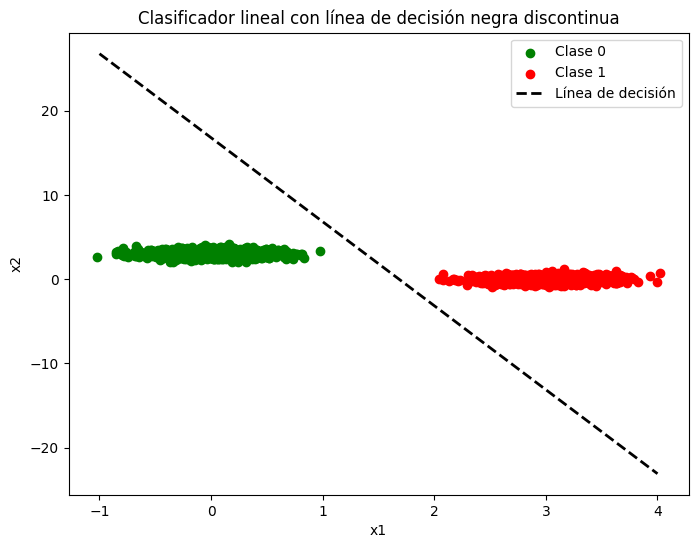

In [11]:
predictions = model(inputs)
w = W.numpy()
b_val = b.numpy()
x = np.linspace(-1, 4, 100)
y = -(w[0, 0] / w[1, 0]) * x + (0.5 - b_val[0]) / w[1, 0]

plt.figure(figsize=(8, 6))
mask0 = (targets[:, 0] == 0).flatten()
mask1 = (targets[:, 0] == 1).flatten()
plt.scatter(inputs[mask0, 0], inputs[mask0, 1], c='green', label='Clase 0')
plt.scatter(inputs[mask1, 0], inputs[mask1, 1], c='red', label='Clase 1')
plt.plot(x, y, 'k--', linewidth=2, label='Línea de decisión')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Clasificador lineal con línea de decisión negra discontinua')
plt.show()

Esta línea discontinua es el umbral de 0.5. Representa el límite donde el modelo deja de pensar que algo es "Verde" (Clase 0) y empieza a creer que es "Rojo" (Clase 1).

Si la línea atraviesa el espacio vacío entre las dos nubes de puntos, ¡significa que el entrenamiento fue un éxito!

Al observar el gráfico, se puede confirmar que los Pesos ($W$) y el Sesgo ($b$) que calculamos con el Descenso por Gradiente son los correctos. Es genial ver cómo una simple ecuación lineal ($z = x \cdot W + b$) logra poner orden en el caos de los datos.

---
# PROBLEMA 2
## Regresión lineal con tf.GradientTape()

Crear conjunto sintético de 100 puntos:
- x: rango [0, 10], distribución uniforme
- y: línea recta + ruido gaussiano (std=0.4)
- Resolver con descenso por gradiente usando tf.GradientTape()

#**Paso 1: Preparación de Datos**
### Generación del Conjunto de Datos: Creamos 100 puntos de datos con una distribución uniforme en x (rango [0, 10]) y añadimos ruido gaussiano (std=0.4) para simular un escenario real.


In [12]:
np.random.seed(42)
tf.random.set_seed(42)

n_points = 100
# x: distribución uniforme en [0, 10]
x_data = np.random.uniform(0, 10, size=(n_points, 1)).astype(np.float32)
# y: línea recta (ej: y = 2x + 1) + ruido gaussiano std=0.4
pendiente_real = 2.0
intercepto_real = 1.0
y_data = (pendiente_real * x_data + intercepto_real +
          np.random.normal(0, 0.4, size=(n_points, 1))).astype(np.float32)

#**Paso 2: Definición del Modelo**
Definición de Parámetros y Modelo: Definimos los pesos (W) y el sesgo (b) como variables entrenables. La predicción se calcula mediante la ecuación lineal $y = x \cdot W + b$.

In [13]:
# Parámetros entrenables
w_reg = tf.Variable(tf.random.uniform(shape=(1, 1)))
b_reg = tf.Variable(tf.zeros(shape=(1,)))

def regression_model(x):
    return tf.matmul(x, w_reg) + b_reg

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

learning_rate_reg = 0.01
epochs = 500

#**Paso 3: Ciclo de Entrenamiento con tf.GradientTape()**
Implementamos el descenso por gradiente manual. Usamos la "cinta" de TensorFlow para calcular los gradientes del Error Cuadrático Medio (MSE) y actualizamos los parámetros en cada Epoch.

In [14]:
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = regression_model(x_data)
        loss = mse_loss(y_data, y_pred)
    gradients = tape.gradient(loss, [w_reg, b_reg])
    w_reg.assign_sub(gradients[0] * learning_rate_reg)
    b_reg.assign_sub(gradients[1] * learning_rate_reg)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.6f}")

Epoch 100, Loss: 0.199376
Epoch 200, Loss: 0.152172
Epoch 300, Loss: 0.136654
Epoch 400, Loss: 0.131552
Epoch 500, Loss: 0.129875


#**Paso 4: Visualización de Resultados**

Comparamos los parámetros aprendidos con los valores reales y visualizamos la línea de mejor ajuste (negra discontinua) sobre los datos originales.

In [15]:
print(f"\nParámetros encontrados:")
print(f"  Pendiente: {w_reg.numpy()[0,0]:.4f} (real: {pendiente_real})")
print(f"  Intercepto: {b_reg.numpy()[0]:.4f} (real: {intercepto_real})")


Parámetros encontrados:
  Pendiente: 1.9898 (real: 2.0)
  Intercepto: 1.0325 (real: 1.0)


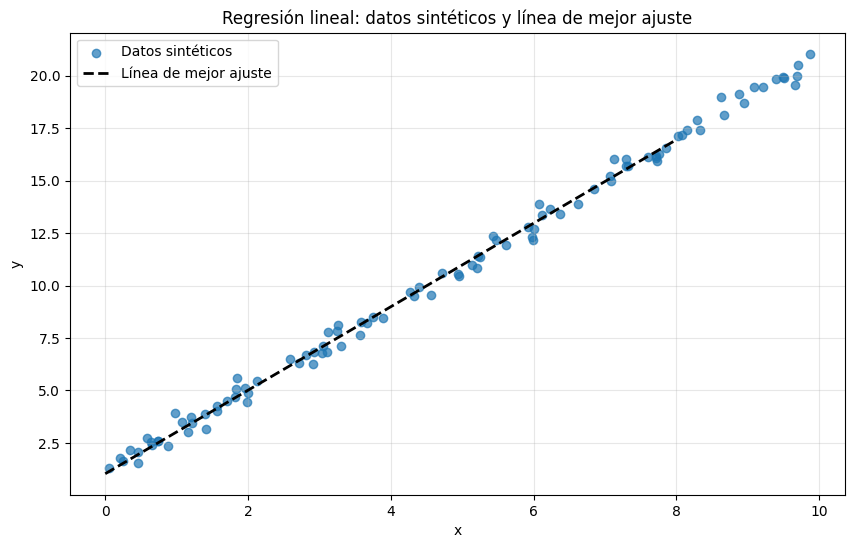

In [16]:
# Graficar puntos de datos y línea de mejor ajuste
x_plot = np.linspace(0, 8, 100).reshape(-1, 1).astype(np.float32)
y_plot = regression_model(x_plot).numpy()

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, alpha=0.7, label='Datos sintéticos')
plt.plot(x_plot, y_plot, 'k--', linewidth=2, label='Línea de mejor ajuste')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión lineal: datos sintéticos y línea de mejor ajuste')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# PROBLEMA 3
## Red neuronal para clasificación binaria (Iris)

Revisión del cuaderno DL_Tarea_1_PartII - Implementación desde cero con NumPy

In [17]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

np.random.seed(42)

In [18]:
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")

TensorFlow: 2.19.0
Keras: 3.13.2


#**Paso 1: Carga y Preprocesamiento del Dataset Iris**
Cargamos el dataset Iris de Scikit-Learn. Para este problema de clasificación binaria, tomamos las dos primeras características (longitud y ancho del sépalo) y filtramos las etiquetas para separar la clase 'Setosa' de las demás. Reorganizamos las matrices para que tengan la forma (características, ejemplos), necesaria para nuestra implementación manual.

In [19]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = (iris.target != 0) * 1

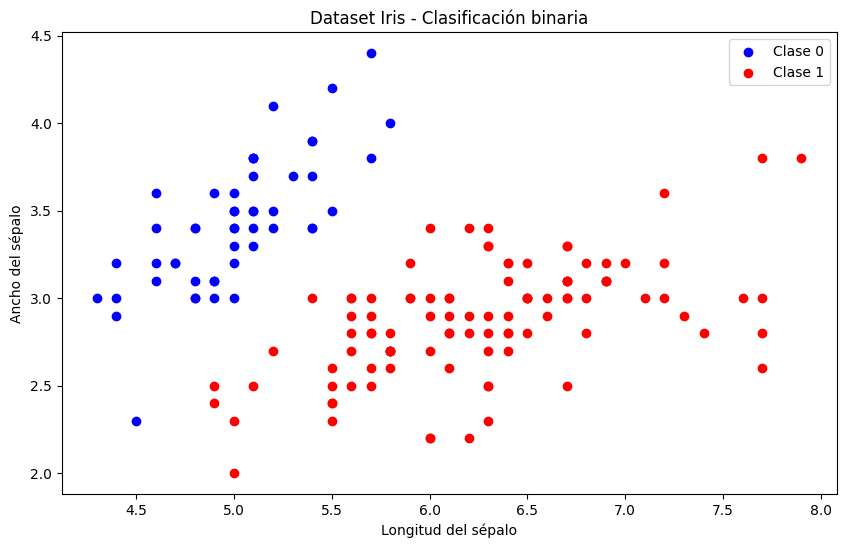

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='b', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='r', label='Clase 1')
plt.legend()
plt.xlabel('Longitud del sépalo')
plt.ylabel('Ancho del sépalo')
plt.title('Dataset Iris - Clasificación binaria')
plt.show()

In [21]:
X = X.T
y = y.reshape(1, 150)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2, 150)
y shape: (1, 150)


**Implementación de funciones: sigmoid, forward/backward propagation, y entrenamiento**

En esta sección es donde realmente se construye el motor del modelo NumPy. Como estudiante, mi meta aquí es entender cómo fluye la información matemáticamente a través de cada capa.

#**Paso 2: Funciones de Activación y Estructura de la Red**
Lo primero que analicé fue la arquitectura en la función layer_sizes. Aquí veo que el modelo está diseñado para recibir 2 datos de entrada (las características de la flor), pasar por una capa intermedia de 4 neuronas ocultas y terminar en 1 neurona de salida. Es una red pequeña pero potente para una clasificación binaria.

*   **La Función Sigmoide:** Al ver la función sigmoid(x), entiendo que su rol es "aplastar" cualquier número para que quede entre 0 y 1. Esto es clave porque, al final del día, lo que queremos es una probabilidad: ¿qué tan seguro está el modelo de que esta flor es de una clase específica?
*  **La Estrategia de Inicio:** En initialize_parameters, me fijé en que se usa np.random.seed(2). Esto es genial porque asegura que siempre que corra el código, los pesos iniciales sean los mismos. Además, multiplicar los pesos por 0.01 es un detalle técnico importante: si los pesos fueran muy grandes, las neuronas se "saturarían" y el modelo dejaría de aprender antes de tiempo.

🚀 **El Viaje de los Datos: Forward y Backward**

Para que la red aprenda, el código gestiona el movimiento de la información en dos sentidos:


*   **Forward Propagation (Hacia adelante):** Al revisar esta función, veo cómo los datos viajan por la red. Se usa np.dot para las multiplicaciones de matrices (el álgebra lineal en acción). Un detalle que me llamó la atención es el uso de tanh en la capa oculta y la sigmoide al final. También es vital el cache: el código guarda ahí los resultados intermedios porque sabe que los necesitaremos más tarde para corregir los errores.
*   **Cálculo del Costo:** En compute_cost, el código mide qué tan perdido está el modelo. Me pareció muy curioso el uso de np.clip; es como un seguro de vida para el código, evitando que intente calcular el logaritmo de cero, lo que causaría un error matemático.
*   **Backward Propagation (El regreso):** Esta es la parte que parece magia, pero es puro cálculo. Aquí es donde el código calcula cuánto "rebotar" el error hacia atrás. Por ejemplo, al ver dZ2 = A2 - Y, entiendo que el modelo está comparando su predicción con la realidad para saber qué tanto falló y usar la regla de la cadena para ajustar cada neurona.
*  **Actualización de Parámetros:** Finalmente, en update_parameters, se aplica lo aprendido. El código usa un learning_rate de 1.2. Al leer esto, noto que es un paso bastante decidido; el profesor configuró el modelo para que aprenda rápido, ajustando los pesos y sesgos restando los gradientes que encontramos en el paso anterior.


In [22]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def layer_sizes(X, Y):
    n_x = X.shape[0]
    n_h = 4
    n_y = Y.shape[0]
    return (n_x, n_h, n_y)

def initialize_parameters(n_x, n_h, n_y):
    np.random.seed(2)
    W1 = 0.01 * np.random.randn(n_h, n_x)
    b1 = np.zeros((n_h, 1))
    W2 = 0.01 * np.random.randn(n_y, n_h)
    b2 = np.zeros((n_y, 1))
    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}

def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

def compute_cost(A2, Y, parameters):
    m = Y.shape[1]
    A2 = np.clip(A2, 1e-8, 1 - 1e-8)
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y)
    return -np.sum(logprobs) / m

def backward_propagation(parameters, cache, X, Y):
    m = X.shape[1]
    W2 = parameters['W2']
    A1, A2 = cache['A1'], cache['A2']
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}

def update_parameters(parameters, grads, learning_rate=1.2):
    parameters['W1'] -= learning_rate * grads['dW1']
    parameters['b1'] -= learning_rate * grads['db1']
    parameters['W2'] -= learning_rate * grads['dW2']
    parameters['b2'] -= learning_rate * grads['db2']
    return parameters

#**Paso 3: Forward Propagation y Función de Costo**
Implementamos la propagación hacia adelante utilizando la función Tanh para la capa oculta. Calculamos el costo utilizando la Entropía Cruzada Logarítmica, que mide la discrepancia entre las predicciones del modelo y las etiquetas reales.

In [23]:
def nn_model(X, Y, n_h, lr=1.2, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    n_x, _, n_y = layer_sizes(X, Y)
    parameters = initialize_parameters(n_x, n_h, n_y)
    for i in range(num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y, parameters)
        grads = backward_propagation(parameters, cache, X, Y)
        parameters = update_parameters(parameters, grads, learning_rate=lr)
        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost:.4f}")
    return parameters

#**Paso 4: Aprendizaje mediante Backward Propagation**
Calculamos los gradientes utilizando la regla de la cadena para determinar cómo cada peso y sesgo afecta al error. Luego, actualizamos los parámetros restando el gradiente multiplicado por la tasa de aprendizaje (learning rate). Este proceso se repite durante 10,000 iteraciones para minimizar el costo.

In [24]:
parameters = nn_model(X, y, n_h=4, lr=0.3, num_iterations=10000, print_cost=True)

Cost after iteration 0: 0.6930
Cost after iteration 1000: 0.0259
Cost after iteration 2000: 0.0156
Cost after iteration 3000: 0.0090
Cost after iteration 4000: 0.0059
Cost after iteration 5000: 0.0044
Cost after iteration 6000: 0.0034
Cost after iteration 7000: 0.0028
Cost after iteration 8000: 0.0023
Cost after iteration 9000: 0.0020


#**Paso 5: Predicción y Evaluación Final**
Utilizamos el modelo entrenado para generar predicciones sobre el conjunto de datos. Convertimos la probabilidad de salida en una etiqueta binaria (0 o 1) usando un umbral de 0.5 y calculamos la precisión final del modelo.

In [25]:
def predict(parameters, X):
    A2, _ = forward_propagation(X, parameters)
    return (A2 > 0.5)

predictions = predict(parameters, X)
accuracy = np.mean((predictions == y).astype(float)) * 100
print(f"Precisión en entrenamiento: {accuracy:.2f}%")

Precisión en entrenamiento: 100.00%


#**Sugerencia de mejora**
Como el resultado obtenido es un 100% de precisión, en Deep Learning, esto suele ser una señal de Overfitting (sobreajuste), especialmente con un modelo de 4 neuronas ocultas para un dataset tan pequeño y linealmente separable como las dos primeras dimensiones de Iris.

**Corrección recomendada**: En un pipeline real se recomienda dividir los datos en Entrenamiento (Train) y Prueba (Test) para asegurar que el modelo realmente aprendió y no solo memorizó.